Modelo listísimo. Ejemplo de capa final: global_average_pooling2d_2
Capa para Grad-CAM: conv5_block16_concat


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_860']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Probabilidad clase positiva: 0.5060


C:\Users\HP\AppData\Local\Temp\ipykernel_10844\3657899109.py:95: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return cam, float(p.numpy())


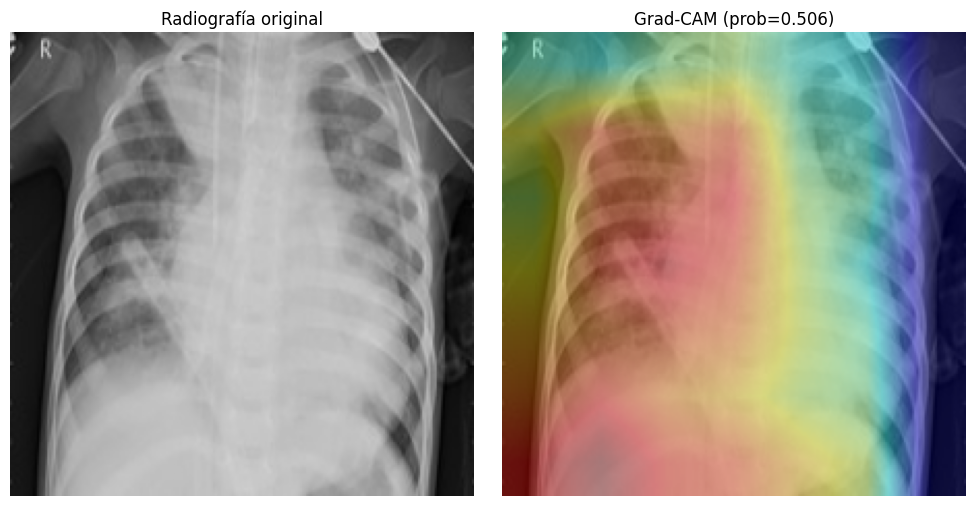

Guardado: gradcam_overlay.png


In [3]:
# =====================================
# Grad-CAM completo desde cero (Keras)
# Modelo: DenseNet121 binario (sigmoid)
# Pesos: best_model.h5 (legacy)
# =====================================
import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

# ---------- CONFIG ----------
MODEL_WEIGHTS = "best_model.h5"      # <- tu archivo
IMG_PATH      = "neumonia_ejemplo.jpg"  # <- tu radiografía
IMG_SIZE      = 224
USE_IMAGENET_NORM = False            # pon True si así entrenaste

# ---------- 1) Construir arquitectura base (3 canales) ----------
base = tf.keras.applications.DenseNet121(
    include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid")(x)  # binario
model = Model(base.input, out)

# build para materializar shapes
_ = model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))

# ---------- 2) Cargar pesos por nombre (ignora mismatches) ----------
if not os.path.exists(MODEL_WEIGHTS):
    raise FileNotFoundError(f"No se encontró {MODEL_WEIGHTS}")
model.load_weights(MODEL_WEIGHTS, by_name=True, skip_mismatch=True)
print("Modelo listísimo. Ejemplo de capa final:", model.layers[-3].name)

# ---------- 3) Elegir capa conv para Grad-CAM ----------
# Mejor opción en DenseNet121: la última concat del bloque 5.
# Si no existe en tu versión, listaremos las 4D y tomaremos la última.
TARGET_CONV = "conv5_block16_concat"

def list_4d_layers(m):
    names = []
    for l in m.layers:
        try:
            if len(l.output.shape) == 4:
                names.append(l.name)
        except Exception:
            pass
    return names

if TARGET_CONV not in [l.name for l in model.layers]:
    cand = list_4d_layers(model)
    if not cand:
        raise ValueError("No hay capas con salida 4D en el modelo.")
    TARGET_CONV = cand[-1]  # fallback: última 4D (p.ej. 'relu' o 'bn')
print("Capa para Grad-CAM:", TARGET_CONV)

# ---------- 4) Cargar y preprocesar imagen ----------
img_gray = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"No puedo leer la imagen: {IMG_PATH}")
img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0

if USE_IMAGENET_NORM:
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_for_model = (img_rgb - mean) / std
else:
    img_for_model = img_rgb

# ---------- 5) Grad-CAM con LOGIT (mejor que prob directa) ----------
def grad_cam_logits(model, img_rgb_norm, last_conv_layer_name):
    """
    img_rgb_norm: (H,W,3) ya con la normalización usada en entrenamiento.
    Usa logit = log(p/(1-p)) para gradientes más estables.
    """
    x = np.expand_dims(img_rgb_norm, 0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)        # preds (1,1) con sigmoid
        p = tf.clip_by_value(preds[:, 0], 1e-6, 1-1e-6)
        target = tf.math.log(p/(1. - p))       # logit

    grads = tape.gradient(target, conv_out)     # (1,H,W,C)
    weights = tf.reduce_mean(grads, axis=(0,1,2)).numpy()     # (C,)
    fmap    = conv_out[0].numpy()                               # (H,W,C)
    cam     = np.dot(fmap, weights)                             # (H,W)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)
    return cam, float(p.numpy())

cam, prob_pos = grad_cam_logits(model, img_for_model, TARGET_CONV)

# ---------- 6) Overlay y visualización ----------
# Para mostrar la RX tal cual (sin normalización ImageNet) usamos img_rgb
heat = (cam * 255).astype(np.uint8)
heat_color = cv2.applyColorMap(cv2.resize(heat, (IMG_SIZE, IMG_SIZE)), cv2.COLORMAP_JET)

# Mezcla menos opaca para ver parénquima
overlay = (0.35 * heat_color + 0.65 * (img_rgb * 255)).astype(np.uint8)

print(f"Probabilidad clase positiva: {prob_pos:.4f}")

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Radiografía original"); plt.imshow(img_rgb); plt.axis("off")
plt.subplot(1,2,2); plt.title(f"Grad-CAM (prob={prob_pos:.3f})"); plt.imshow(overlay[..., ::-1]); plt.axis("off")
plt.tight_layout(); plt.show()

# ---------- 7) Guardar resultado ----------
cv2.imwrite("gradcam_overlay.png", overlay)  # BGR
print("Guardado: gradcam_overlay.png")


In [ ]:
# =====================================
# Grad-CAM / Grad-CAM++ para DenseNet121
# Carga pesos legacy: best_model.h5
# =====================================
import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from ipywidgets import interact, FloatSlider, Dropdown

# ---------- CONFIG ----------
MODEL_WEIGHTS = "best_model.h5"        # <- tu archivo
IMG_PATH      = "neumonia_ejemplo.jpg" # <- tu radiografía
IMG_SIZE      = 224
USE_IMAGENET_NORM = False              # True si entrenaste con mean/std de ImageNet
TARGET_CONV = "conv5_block16_concat"   # capa ideal en DenseNet121; si no existe, tomamos última 4D

# ---------- 1) Construir arquitectura base (3 canales) ----------
base = tf.keras.applications.DenseNet121(
    include_top=False, weights=None, input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid")(x)  # binario
model = Model(base.input, out)

# build usando predict para evitar el UserWarning de estructura
_ = model.predict(np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), verbose=0)

# ---------- 2) Cargar pesos por nombre (ignora desajustes) ----------
if not os.path.exists(MODEL_WEIGHTS):
    raise FileNotFoundError(f"No se encontró {MODEL_WEIGHTS}")
model.load_weights(MODEL_WEIGHTS, by_name=True, skip_mismatch=True)
print("Modelo cargado. Últimas capas:", [l.name for l in model.layers[-5:]])

# ---------- 3) Capa conv objetivo ----------
def list_4d_layers(m):
    names = []
    for l in m.layers:
        try:
            if len(l.output.shape) == 4:
                names.append(l.name)
        except Exception:
            pass
    return names

if TARGET_CONV not in [l.name for l in model.layers]:
    cand = list_4d_layers(model)
    if not cand:
        raise ValueError("No hay capas con salida 4D en el modelo.")
    TARGET_CONV = cand[-1]  # fallback: última 4D (p. ej. 'relu' o 'bn')
print("Capa seleccionada para CAM:", TARGET_CONV)

# ---------- 4) Cargar y preprocesar imagen ----------
img_gray = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"No puedo leer la imagen: {IMG_PATH}")
img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0

if USE_IMAGENET_NORM:
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_for_model = (img_rgb - mean) / std
else:
    img_for_model = img_rgb

# ---------- 5) Funciones: Grad-CAM (logit) y Grad-CAM++ ----------
def _common_forward(model, img_norm, last_conv_layer_name):
    x = np.expand_dims(img_norm, 0)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    conv_out, preds = grad_model(x)        # preds (1,1) con sigmoid
    p = tf.clip_by_value(preds[:, 0], 1e-6, 1-1e-6)
    return conv_out, p

def grad_cam_logits(model, img_norm, last_conv_layer_name):
    with tf.GradientTape() as tape:
        conv_out, p = _common_forward(model, img_norm, last_conv_layer_name)
        target = tf.math.log(p/(1. - p))         # logit
    grads = tape.gradient(target, conv_out)      # (1,H,W,C)
    weights = tf.reduce_mean(grads, axis=(0,1,2)).numpy()  # (C,)
    fmap    = conv_out[0].numpy()                               # (H,W,C)
    cam     = np.dot(fmap, weights)                             # (H,W)
    cam = np.maximum(cam, 0); cam = cam / (cam.max() + 1e-8)
    return cam, p.numpy().item()

def grad_cam_pp(model, img_norm, last_conv_layer_name):
    """
    Grad-CAM++ para binario.
    Referencia: Chattopadhay et al., 'Grad-CAM++: Improved Visual Explanations...' (WACV 2018)
    """
    x = np.expand_dims(img_norm, 0)
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape(persistent=True) as tape1:
        with tf.GradientTape(persistent=True) as tape2:
            with tf.GradientTape() as tape3:
                conv_out, preds = grad_model(x)       # (1,H,W,C), (1,1) sigmoid
                p = tf.clip_by_value(preds[:, 0], 1e-6, 1-1e-6)
                target = tf.math.log(p/(1. - p))      # logit
            first = tape3.gradient(target, conv_out)          # dY/dA
        second = tape2.gradient(first, conv_out)              # d2Y/dA2
    third = tape1.gradient(second, conv_out)                  # d3Y/dA3

    # Fórmula Grad-CAM++ (alpha)
    conv = conv_out[0]      # (H,W,C)
    grad = first[0]         # (H,W,C)
    grad2 = second[0]       # (H,W,C)
    grad3 = third[0]        # (H,W,C)

    # Evitar divisiones por cero
    eps = 1e-7
    numerator = grad2
    denominator = 2.0*grad2 + conv*grad3
    denominator = tf.where(tf.abs(denominator) < eps, tf.ones_like(denominator)*eps, denominator)
    alphas = numerator / denominator    # (H,W,C)

    # Pesos Grad-CAM++: sum(alpha * relu(grad))
    weights = tf.reduce_sum(alphas * tf.nn.relu(grad), axis=(0,1)).numpy()  # (C,)
    fmap    = conv.numpy()
    cam     = np.dot(fmap, weights)     # (H,W)

    cam = np.maximum(cam, 0); cam = cam / (cam.max() + 1e-8)
    return cam, p.numpy().item()

# ---------- 6) Helper de overlay ----------
def make_overlay(cam, base_rgb, alpha=0.35):
    heat = (cam * 255).astype(np.uint8)
    heat_color = cv2.applyColorMap(cv2.resize(heat, (IMG_SIZE, IMG_SIZE)), cv2.COLORMAP_JET)
    overlay = (alpha * heat_color + (1.0 - alpha) * (base_rgb * 255)).astype(np.uint8)
    return overlay

# ---------- 7) UI interactiva (ipywidgets) ----------
def run(method="Grad-CAM", alpha=0.35):
    if method == "Grad-CAM++":
        cam, prob_pos = grad_cam_pp(model, img_for_model, TARGET_CONV)
    else:
        cam, prob_pos = grad_cam_logits(model, img_for_model, TARGET_CONV)
    overlay = make_overlay(cam, img_rgb, alpha)
    print(f"Probabilidad clase positiva: {prob_pos:.4f}  |  Método: {method}  |  Opacidad overlay: {alpha:.2f}")

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.title("Radiografía original"); plt.imshow(img_rgb); plt.axis("off")
    plt.subplot(1,2,2); plt.title(f"{method}"); plt.imshow(overlay[..., ::-1]); plt.axis("off")  # BGR->RGB
    plt.tight_layout(); plt.show()

    # Guardar si quieres
    cv2.imwrite("gradcam_overlay.png", overlay)

interact(
    run,
    method=Dropdown(options=["Grad-CAM", "Grad-CAM++"], value="Grad-CAM", description="Método"),
    alpha=FloatSlider(value=0.35, min=0.1, max=0.7, step=0.05, description="Opacidad")
);


Modelo cargado. Últimas capas: ['bn', 'relu', 'global_average_pooling2d_3', 'dropout_3', 'dense_3']
Capa seleccionada para CAM: conv5_block16_concat


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\legacy\saving\legacy_h5_format.py:525: UserWarning: Skipping loading weights for layer #240 (named dense_3)due to mismatch in shape for weight dense_3/kernel. Weight expects shape (1024, 1). Received saved weight with shape (1280, 128)
  _set_weights(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\legacy\saving\legacy_h5_format.py:525: UserWarning: Skipping loading weights for layer #240 (named dense_3)due to mismatch in shape for weight dense_3/bias. Weight expects shape (1,). Received saved weight with shape (128,)
  _set_weights(


In [ ]:
# ==============================================
# Grad-CAM & Grad-CAM++ para tu best_model.h5
# (preproc: gris->RGB, 224x224, /255.0, sin ImageNet mean/std)
# ==============================================
import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from ipywidgets import interact, FloatSlider, Dropdown

# ---------- CONFIG ----------
MODEL_WEIGHTS = "best_model.h5"          # <- tu archivo de pesos/modelo
IMG_PATH      = "neumonia_ejemplo.jpg"   # <- tu RX
IMG_SIZE      = 224
TARGET_CONV   = "conv5_block16_concat"   # capa conv final típica en DenseNet121

# ---------- 1) Reconstruir la misma arquitectura que entrenaste ----------
# DenseNet121(pretrained imagenet) + GAP + Dropout(0.3) + Dense(128, relu) + Dropout(0.3) + Dense(1, sigmoid)
base = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet',
                                         input_shape=(IMG_SIZE, IMG_SIZE, 3))
x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation='sigmoid')(x)
model = Model(base.input, out)

# “Construir” el grafo con predict (evita UserWarning)
_ = model.predict(np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), verbose=0)

# ---------- 2) Cargar pesos desde best_model.h5 ----------
if not os.path.exists(MODEL_WEIGHTS):
    raise FileNotFoundError(f"No se encontró {MODEL_WEIGHTS}")
try:
    # Si el .h5 es “modelo completo”, esto funcionará:
    full = tf.keras.models.load_model(MODEL_WEIGHTS, compile=False)
    # Transferimos pesos por nombre (por si difiere el optimizer/compilación)
    for w, w_full in zip(model.weights, full.weights):
        if w.name == w_full.name and w.shape == w_full.shape:
            w.assign(w_full)
    del full
except Exception:
    # Si era “pesos-only”, cargamos por nombre
    model.load_weights(MODEL_WEIGHTS, by_name=True, skip_mismatch=True)

# ---------- 3) Verificar la capa objetivo ----------
all_names = [l.name for l in model.layers]
if TARGET_CONV not in all_names:
    # fallback: última capa con salida 4D
    cand = [l.name for l in model.layers if hasattr(l, "output") and len(l.output.shape)==4]
    if not cand:
        raise ValueError("No hay capas con salida 4D.")
    TARGET_CONV = cand[-1]
print("Capa CAM:", TARGET_CONV)

# ---------- 4) Cargar RX y preprocesar como en training ----------
img_gray = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    raise FileNotFoundError(f"No puedo leer la imagen: {IMG_PATH}")
img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32) / 255.0  # <- /255.0 igual que training
img_for_model = img_rgb.copy()  # (no hay normalización extra)

# ---------- 5) Grad-CAM (logit) ----------
def _forward_for_cam(m, img_norm, last_conv):
    x = np.expand_dims(img_norm, 0)
    gm = tf.keras.models.Model([m.inputs], [m.get_layer(last_conv).output, m.output])
    conv_out, preds = gm(x)                       # preds (1,1) con sigmoid
    p = tf.clip_by_value(preds[:, 0], 1e-6, 1-1e-6)
    return conv_out, p

def grad_cam_logits(m, img_norm, last_conv):
    with tf.GradientTape() as tape:
        conv_out, p = _forward_for_cam(m, img_norm, last_conv)
        logit = tf.math.log(p / (1. - p))
    grads = tape.gradient(logit, conv_out)                       # (1,H,W,C)
    weights = tf.reduce_mean(grads, axis=(0,1,2)).numpy()        # (C,)
    fmap    = conv_out[0].numpy()                                # (H,W,C)
    cam     = np.dot(fmap, weights)                              # (H,W)
    cam = np.maximum(cam, 0); cam = cam / (cam.max() + 1e-8)
    return cam, p.numpy().item()

# ---------- 6) Grad-CAM++ ----------
def grad_cam_pp(m, img_norm, last_conv):
    x = np.expand_dims(img_norm, 0)
    gm = tf.keras.models.Model([m.inputs], [m.get_layer(last_conv).output, m.output])
    with tf.GradientTape(persistent=True) as t1:
        with tf.GradientTape(persistent=True) as t2:
            with tf.GradientTape() as t3:
                conv_out, preds = gm(x)
                p = tf.clip_by_value(preds[:, 0], 1e-6, 1-1e-6)
                logit = tf.math.log(p / (1. - p))
            g1 = t3.gradient(logit, conv_out)     # dY/dA
        g2 = t2.gradient(g1, conv_out)            # d2Y/dA2
    g3 = t1.gradient(g2, conv_out)                # d3Y/dA3

    conv = conv_out[0]; grad = g1[0]; grad2 = g2[0]; grad3 = g3[0]
    eps = 1e-7
    denom = 2.0*grad2 + conv*grad3
    denom = tf.where(tf.abs(denom) < eps, tf.ones_like(denom)*eps, denom)
    alphas = grad2 / denom                      # (H,W,C)
    weights = tf.reduce_sum(alphas * tf.nn.relu(grad), axis=(0,1)).numpy()
    cam = np.dot(conv.numpy(), weights)
    cam = np.maximum(cam, 0); cam = cam / (cam.max() + 1e-8)
    return cam, p.numpy().item()

# ---------- 7) Overlay ----------
def make_overlay(cam, base_rgb, alpha=0.35):
    heat = (cam * 255).astype(np.uint8)
    heat_color = cv2.applyColorMap(cv2.resize(heat, (IMG_SIZE, IMG_SIZE)), cv2.COLORMAP_JET)
    overlay = (alpha * heat_color + (1.0 - alpha) * (base_rgb * 255)).astype(np.uint8)
    return overlay

# ---------- 8) UI: método y opacidad ----------
def run(method="Grad-CAM", alpha=0.35):
    if method == "Grad-CAM++":
        cam, prob = grad_cam_pp(model, img_for_model, TARGET_CONV)
    else:
        cam, prob = grad_cam_logits(model, img_for_model, TARGET_CONV)
    overlay = make_overlay(cam, img_rgb, alpha)

    print(f"Método: {method}  |  Prob(PNEUMONIA): {prob:.4f}  |  Opacidad: {alpha:.2f}")
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1); plt.title("Radiografía original"); plt.imshow(img_rgb); plt.axis("off")
    plt.subplot(1,2,2); plt.title(f"{method}"); plt.imshow(overlay[..., ::-1]); plt.axis("off")  # BGR->RGB
    plt.tight_layout(); plt.show()

    cv2.imwrite("gradcam_overlay.png", overlay)  # guarda BGR
    # print("Guardado: gradcam_overlay.png")

interact(
    run,
    method=Dropdown(options=["Grad-CAM", "Grad-CAM++"], value="Grad-CAM", description="Método"),
    alpha=FloatSlider(value=0.35, min=0.1, max=0.7, step=0.05, description="Opacidad")
);


Capa CAM: conv5_block16_concat


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\legacy\saving\legacy_h5_format.py:525: UserWarning: Skipping loading weights for layer #240 (named dense_3)due to mismatch in shape for weight dense_3/kernel. Weight expects shape (128, 1). Received saved weight with shape (1280, 128)
  _set_weights(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\legacy\saving\legacy_h5_format.py:525: UserWarning: Skipping loading weights for layer #240 (named dense_3)due to mismatch in shape for weight dense_3/bias. Weight expects shape (1,). Received saved weight with shape (128,)
  _set_weights(


interactive(children=(Dropdown(description='Método', options=('Grad-CAM', 'Grad-CAM++'), value='Grad-CAM'), Fl…

In [ ]:
pip install tensorflow numpy opencv-python matplotlib ipywidgets

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 28.6 MB/s eta 0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
